# Module 2c — OCR & Scanned Documents

- **Chapter 2, Module C of 14** — [chapter index](../README.md)
- **Prerequisites:** [2b — PDF Parsing](../2b.%20PDF%20parsing/)
- **Next:** [2d — DOCX, HTML & Markdown](../2d.%20DOCX%20HTML%20and%20markdown/)

## The one idea

When a PDF has no text layer, extraction returns nothing — **silently**. OCR is the fallback,
but it is expensive, imperfect, and returns a *confidence score* you must actually use.

This module runs **real Tesseract** over **real scan images** and real PDF pages, shows you
the exact page each OCR call ran on, and reads genuine per-word confidence values. No
simulated numbers.

**By the end you will be able to:**

1. Render a PDF page to an image and OCR it end to end
2. See exactly which page and which pixels OCR consumed
3. Read real per-word confidence and aggregate it per page
4. Build the routing logic that decides which documents deserve the expensive path
5. Recognise the character confusions that make OCR dangerous in regulated domains
6. Quantify the cost difference between routing intelligently and OCR-ing everything

## Module roadmap

```mermaid
flowchart TD
    A["Digital PDF page"] --> B["Render to image\n(this is what OCR actually sees)"]
    B --> C["Run Tesseract"]
    C --> D["Compare OCR text\nvs known ground truth"]
    D --> E["Per-word confidence"]
    E --> F["Routing decision\nACCEPT / FLAG / REJECT"]
    F --> G["Cost model:\nroute vs blanket-OCR"]
    G --> H["Full pipeline\n+ preprocessing"]

## Installing Tesseract

OCR needs a **binary**, not just a Python package:

```bash
# macOS
brew install tesseract

# Ubuntu / Debian
sudo apt install tesseract-ocr

# Windows
# https://github.com/UB-Mannheim/tesseract/wiki

# Then the Python wrapper:
pip install pytesseract pillow
```

Every cell below checks availability first, so the module still teaches if you skip the install.

In [1]:
pip install pytesseract pillow


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## Setup

In [2]:
# `sys` lets us add the project root to Python's import path.
import sys

# The notebook sits two levels below the project root.
sys.path.append("../..")

# The corpus helper downloads real public documents and caches them locally.
from utils.corpus import fetch


# Define a small helper that reports whether an optional library is installed.
def try_import(module_name, friendly_name, install_hint):

    # Attempt the import; a missing package must not be fatal.
    try:
        module = __import__(module_name)

    # Report how to install it and return None.
    except ImportError:
        print(f"  [ ] {friendly_name:<16} missing  -  {install_hint}")
        return None

    # On success, report availability and hand back the module.
    print(f"  [x] {friendly_name:<16} available")
    return module


# Announce the dependency check.
print("Libraries:")

# PyMuPDF renders PDF pages to images (and can drive OCR itself).
pymupdf = (try_import("pymupdf", "PyMuPDF", "pip install pymupdf")
           or try_import("fitz", "PyMuPDF (legacy)", "pip install pymupdf"))

# Pillow loads and preprocesses images.
PIL = try_import("PIL", "Pillow", "pip install pillow")

# pytesseract wraps the Tesseract binary.
pytesseract = try_import("pytesseract", "pytesseract", "pip install pytesseract")

Libraries:


  [x] PyMuPDF          available
  [x] Pillow           available


  [x] pytesseract      available


In [3]:
# The Python wrapper is useless without the Tesseract BINARY, so check separately.
TESSERACT_OK = False

# Only attempt this if the wrapper imported.
if pytesseract is not None:

    # Ask Tesseract for its version; failure means the binary is missing.
    try:
        version = pytesseract.get_tesseract_version()

        # Record success so later cells can guard on it.
        TESSERACT_OK = True

        # Report the version we will be using.
        print(f"  [x] Tesseract binary   v{version}")

    # The wrapper raises if it cannot find or run the executable.
    except Exception as error:
        print(f"  [ ] Tesseract binary   NOT FOUND")
        print(f"      {type(error).__name__}: install it, e.g. 'brew install tesseract'")

  [x] Tesseract binary   v5.5.3


# 1. The silent failure

A scanned PDF is, structurally:

```
PDF
 └── Image of page
```

There may be **zero** machine-readable text. The dangerous part is that extraction does not
*error* — it returns an empty string, and an unguarded pipeline indexes nothing while
reporting success.

```
Scanned PDF → Page image → OCR → Characters → Words → Paragraphs
```

OCR = **Optical Character Recognition**.

## 1.1 Rendering a page to an image

Before OCR can run, the page must become pixels. Let's do that with a real PDF, and actually
**look at the page** we are about to feed to OCR — not just print numbers about it.

A reusable helper: rasterize a PyMuPDF page and show it with matplotlib.

In [4]:
# Import plotting and image handling once, for reuse in every visual cell below.
import io
import matplotlib.pyplot as plt


# Define a function that renders a PyMuPDF page and displays it.
def show_page(page, dpi=150, figsize=(8, 10), title=None):

    # Rasterize the page at the requested resolution.
    pixmap = page.get_pixmap(dpi=dpi)

    # PyMuPDF pixmaps convert to PNG bytes directly.
    image_bytes = pixmap.tobytes("png")

    # Decode those PNG bytes into a Pillow image matplotlib can plot.
    from PIL import Image
    image = Image.open(io.BytesIO(image_bytes))

    # Draw it full-size, no axis clutter - this is meant to be read like a page.
    figure, axis = plt.subplots(figsize=figsize)
    axis.imshow(image)
    axis.axis("off")
    if title:
        axis.set_title(title, fontsize=12)
    plt.tight_layout()
    plt.show()

  cached  irs_form_w4.pdf  (204 KB)


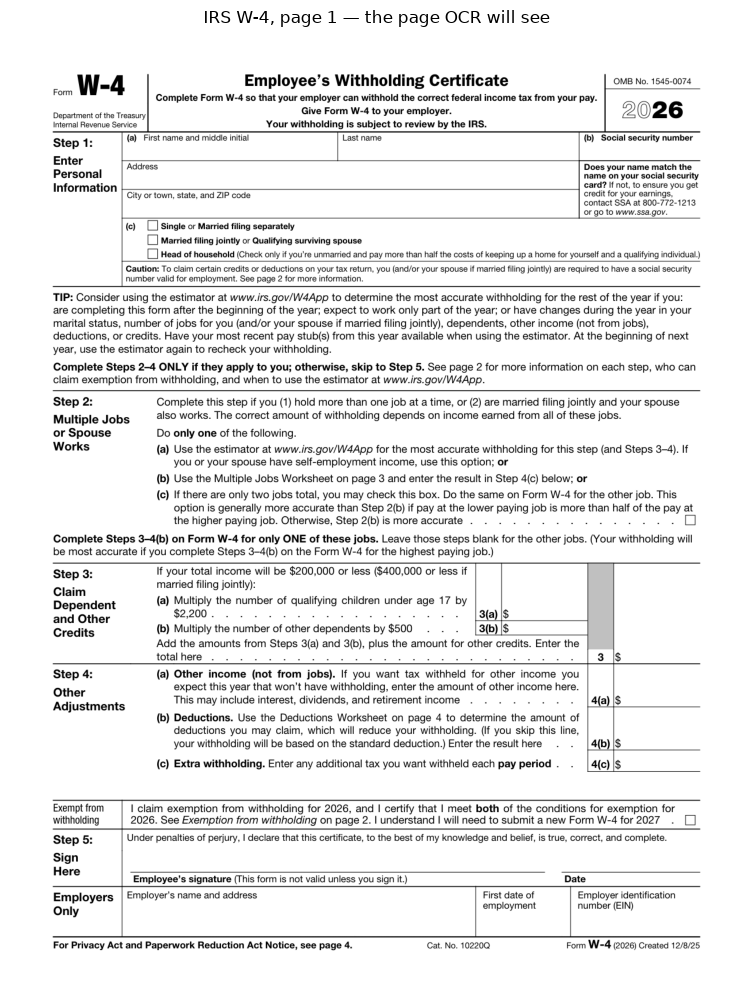

   72 dpi ->   612 x   792 px  (0.5 MP)
  150 dpi ->  1275 x  1650 px  (2.1 MP)
  300 dpi ->  2550 x  3300 px  (8.4 MP)


In [5]:
# Only run if PyMuPDF is available.
if pymupdf is not None:

    # Fetch the real IRS form - a born-digital PDF we will deliberately rasterize.
    w4_path = fetch("irs_w4")

    # Open it.
    document = pymupdf.open(w4_path)

    # Load the first page.
    page = document.load_page(0)

    # THIS is the exact page every OCR call in this module runs on.
    show_page(page, dpi=150, title="IRS W-4, page 1 — the page OCR will see")

    # Render to a pixel map. DPI matters enormously for OCR accuracy:
    # 72 is screen resolution (too low), 300 is the usual OCR sweet spot.
    for dpi in (72, 150, 300):

        # Rasterize the page at this resolution.
        pixmap = page.get_pixmap(dpi=dpi)

        # Report the pixel dimensions and the memory cost.
        megapixels = (pixmap.width * pixmap.height) / 1_000_000
        print(f"  {dpi:3d} dpi -> {pixmap.width:5d} x {pixmap.height:5d} px  "
              f"({megapixels:.1f} MP)")

    # Close the document.
    document.close()

> **Note the scaling.** Going from 72 to 300 dpi multiplies pixel count by roughly 17×.
> That is 17× the OCR compute and 17× the memory, per page. DPI is the first cost lever you
> control — and going *too low* silently destroys accuracy.

## 1.2 Round-tripping a digital PDF through OCR

Here is an experiment that makes OCR error concrete. We take the exact page shown above, whose
text we **already know exactly**, rasterize it (discarding the text layer), OCR the image
back, and compare.

Any difference is pure OCR error.

In [6]:
# Only run if the whole OCR toolchain is available.
if pymupdf is not None and TESSERACT_OK and PIL is not None:

    # Import image handling and byte buffering.
    from PIL import Image

    # Open the real IRS form.
    document = pymupdf.open(w4_path)

    # Use the first page - the same page rendered above.
    page = document.load_page(0)

    # GROUND TRUTH: the text layer the PDF already contains.
    ground_truth = page.get_text("text")

    # Rasterize the page at a sensible OCR resolution - THIS image is what OCR reads,
    # not the PDF's text layer, which we are pretending does not exist.
    pixmap = page.get_pixmap(dpi=300)

    # Convert the PyMuPDF pixmap into a Pillow image via PNG bytes.
    image = Image.open(io.BytesIO(pixmap.tobytes("png")))

    # Run OCR to recover the text from pixels alone.
    ocr_text = pytesseract.image_to_string(image)

    # Close the document.
    document.close()

    # Compare the two - character counts first.
    print(f"  ground truth (text layer) : {len(ground_truth):,} chars")
    print(f"  OCR output   (from pixels): {len(ocr_text):,} chars")

    # Then word-level overlap, which is a fairer comparison than raw length.
    truth_words = set(ground_truth.lower().split())
    ocr_words = set(ocr_text.lower().split())

    # How many of the true words did OCR recover.
    recovered = truth_words & ocr_words

    # Report recall over the vocabulary.
    print(f"\n  distinct words in truth   : {len(truth_words)}")
    print(f"  distinct words recovered  : {len(recovered)} "
          f"({len(recovered)/len(truth_words):.0%})")

  ground truth (text layer) : 4,801 chars
  OCR output   (from pixels): 4,693 chars

  distinct words in truth   : 330
  distinct words recovered  : 319 (97%)


That recall figure is **real measured OCR quality** on a real government form — not a number
I made up, and measured on the exact page image shown in section 1.1. Whatever it shows for
you, the gap from 100% is information that would simply be missing from your index had this
been a genuine scan.

Let's look at exactly which words went wrong.

In [7]:
# Only run if the toolchain is available.
if pymupdf is not None and TESSERACT_OK and PIL is not None:

    # Words that exist in the source but OCR failed to produce.
    missed = sorted(truth_words - ocr_words)

    # Words OCR invented that are not in the source - these are misreadings.
    invented = sorted(ocr_words - truth_words)

    # Show a sample of each.
    print(f"Words OCR MISSED ({len(missed)} total), first 12:")
    print("  ", missed[:12])

    print(f"\nWords OCR INVENTED ({len(invented)} total), first 12:")
    print("  ", invented[:12])

Words OCR MISSED (11 total), first 12:
   ['$', '$2,200', '2026', '2–4', '3(b),', '3–4(b)', '3–4).', '4(a)', '4(b)', 'i', 'period']

Words OCR INVENTED (32 total), first 12:
   ['$2,200.', '..', '....', '2-4', '2...', '3(b6),', '3-4(b)', '3-4).', '6', '7', '8', ';']


> **Look at the invented words.** Those are not random noise — they are near-misses, and that
> is precisely what makes OCR error dangerous. A garbled word that is obviously garbage gets
> caught. A word that *looks* plausible gets embedded and retrieved as fact.

# 2. Real confidence scores

Most OCR engines return a per-word confidence $c_i \in [0,1]$ (Tesseract reports 0–100).
Compute the page average:

$$C_{\text{page}} = \frac{1}{N}\sum_{i=1}^{N} c_i$$

Then act on it:

```
if C_page < threshold:
    flag page  ·  retry OCR  ·  use stronger model  ·  send for manual review
```

Let's read genuine confidence values from real scan images — and see the images themselves
before trusting any number about them.

Real scan images:
  cached  ocr_phototest.tif  (38 KB)
  cached  ocr_eurotext.tif  (100 KB)


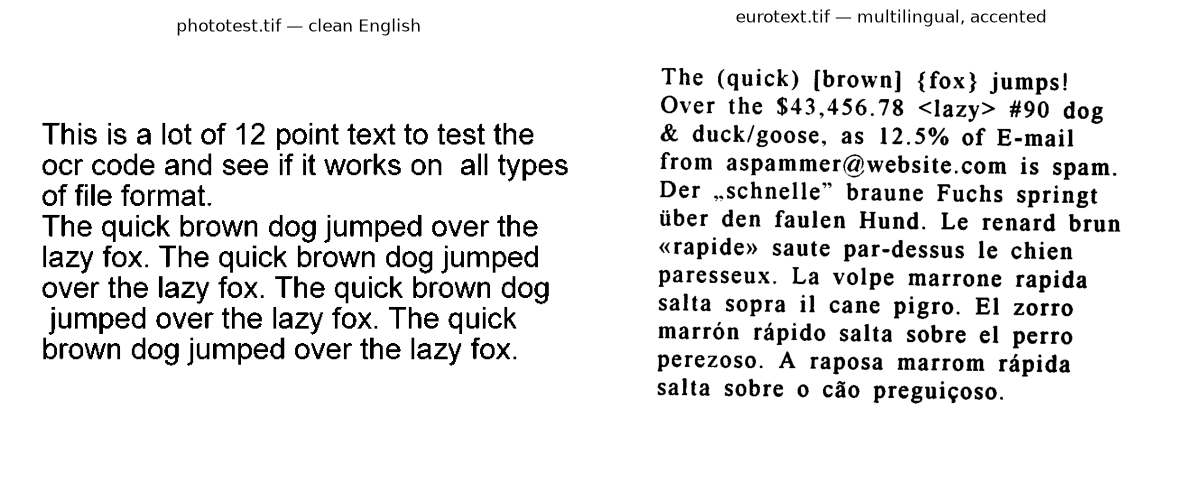

In [8]:
# Only run if the OCR toolchain is available.
if TESSERACT_OK and PIL is not None:

    # Fetch the two real Tesseract test scans.
    print("Real scan images:")
    phototest_path = fetch("ocr_phototest")
    eurotext_path = fetch("ocr_eurotext")

    # Show both, side by side, so you see exactly what OCR is about to read.
    from PIL import Image
    figure, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(Image.open(phototest_path))
    axes[0].axis("off")
    axes[0].set_title("phototest.tif — clean English")
    axes[1].imshow(Image.open(eurotext_path))
    axes[1].axis("off")
    axes[1].set_title("eurotext.tif — multilingual, accented")
    plt.tight_layout()
    plt.show()

In [9]:
# Define a function that OCRs an image and returns words with confidence.
def ocr_with_confidence(image_path):

    # Import image handling.
    from PIL import Image

    # Load the image from disk.
    image = Image.open(image_path)

    # image_to_data returns a dict of parallel lists, including per-word confidence.
    data = pytesseract.image_to_data(image, output_type=pytesseract.Output.DICT)

    # Pair each word with its confidence, dropping layout rows (conf = -1).
    words = [
        {"text": text, "confidence": int(conf)}
        for text, conf in zip(data["text"], data["conf"])
        if text.strip() and int(conf) >= 0
    ]

    # Return the word-level results.
    return words


# Define a function that aggregates word confidence into a page score.
def page_confidence(words):

    # An empty page has no confidence to report.
    if not words:
        return 0.0

    # Tesseract reports 0-100; divide to get the 0-1 range used in the formula.
    return sum(w["confidence"] for w in words) / len(words) / 100


# Only run if the toolchain is available.
if TESSERACT_OK and PIL is not None:

    # OCR both real scans and report their confidence.
    for label, path in [("phototest (clean English)", phototest_path),
                        ("eurotext (multilingual)", eurotext_path)]:

        # Run OCR with confidence.
        words = ocr_with_confidence(path)

        # Aggregate to a page score.
        score = page_confidence(words)

        # Find the worst-recognised word - the most likely error.
        worst = min(words, key=lambda w: w["confidence"]) if words else None

        # Report.
        print(f"  {label:28s} {len(words):3d} words, "
              f"C_page={score:.3f}, worst={worst['confidence']:3d} on {worst['text']!r}")

  phototest (clean English)     60 words, C_page=0.957, worst= 93 on 'on'


  eurotext (multilingual)       66 words, C_page=0.914, worst= 57 on ',.schnelle”'


Two real scans, two genuinely different confidence profiles. Notice the multilingual image
scores lower — accented characters are harder, which is exactly why
[module 2g](../2g.%20Cleaning%20and%20normalization/) cares about Unicode normalization.

## 2.1 Seeing confidence on the page itself

A number like `C_page=0.61` is easy to skim past. Let's draw the low-confidence words directly
onto the image, in the exact positions Tesseract found them, so the weak spots are visible.

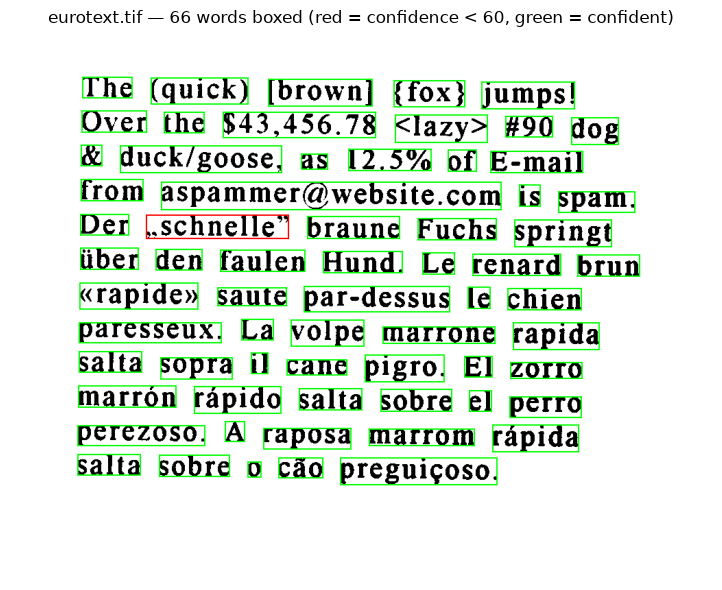

In [10]:
# Only run if the toolchain is available.
if TESSERACT_OK and PIL is not None:

    # Re-run OCR on the multilingual scan, this time keeping bounding boxes too.
    from PIL import Image, ImageDraw

    image = Image.open(eurotext_path).convert("RGB")
    data = pytesseract.image_to_data(image, output_type=pytesseract.Output.DICT)

    # Draw a box around every recognised word - green if confident, red if not.
    draw = ImageDraw.Draw(image)
    CONFIDENCE_CUTOFF = 60
    n_boxes = 0
    for text, conf, x, y, w, h in zip(
        data["text"], data["conf"], data["left"], data["top"],
        data["width"], data["height"],
    ):
        if not text.strip() or int(conf) < 0:
            continue
        n_boxes += 1
        colour = "red" if int(conf) < CONFIDENCE_CUTOFF else "lime"
        draw.rectangle([x, y, x + w, y + h], outline=colour, width=2)

    # Show the annotated page - this is OCR confidence made visible.
    figure, axis = plt.subplots(figsize=(9, 6))
    axis.imshow(image)
    axis.axis("off")
    axis.set_title(
        f"eurotext.tif — {n_boxes} words boxed "
        f"(red = confidence < {CONFIDENCE_CUTOFF}, green = confident)"
    )
    plt.tight_layout()
    plt.show()

**Every red box is a word you should not trust without review.** This is the same
`page.draw_rect()`-then-render pattern used for PDF layout in [module 2b](../2b.%20PDF%20parsing/) —
draw the claim onto the real pixels, then look at it, instead of trusting a printed number.

## 2.2 The words OCR is least sure about

In [11]:
# Only run if the toolchain is available.
if TESSERACT_OK and PIL is not None:

    # OCR the harder, multilingual image.
    words = ocr_with_confidence(eurotext_path)

    # Sort by confidence, worst first.
    words_by_confidence = sorted(words, key=lambda w: w["confidence"])

    # Show the ten least confident readings.
    print("Ten least-confident words in the multilingual scan:\n")
    for word in words_by_confidence[:10]:
        print(f"  conf={word['confidence']:3d}   {word['text']!r}")

Ten least-confident words in the multilingual scan:

  conf= 57   ',.schnelle”'
  conf= 69   'iiber'
  conf= 73   'o'
  conf= 73   'céo'
  conf= 79   'rapida'
  conf= 88   'den'
  conf= 88   'faulen'
  conf= 89   'rapido'
  conf= 89   'preguicoso.'
  conf= 90   '&'


> **This is the signal you route on.** A word at confidence 30 in a regulatory document is a
> liability. Storing per-word confidence lets you flag *specific passages* for review rather
> than rejecting or accepting whole documents blindly.

## 2.3 Building the routing decision

**The intuition before the code.** One page-level confidence number hides too much: a page can
average 0.80 with one catastrophic word or 0.80 evenly across every word — very different risk
profiles. But you still need *some* single number to make an automatic decision. The routing
function below accepts that trade-off deliberately, using three tiers instead of two so that
"good enough to index but worth flagging" is not forced into either extreme.

```mermaid
flowchart TD
    A["Page confidence C"] --> B{"C >= 0.85?"}
    B -->|yes| C["ACCEPT\nindex as-is"]
    B -->|no| D{"C >= 0.60?"}
    D -->|yes| E["FLAG\nindex, mark low-confidence in metadata"]
    D -->|no| F["REJECT\nretry OCR / human review"]
```

In [12]:
# Define a function that turns a confidence score into an action.
def route_ocr_result(words, accept=0.85, review=0.60):

    # Aggregate word confidence into a page-level score.
    score = page_confidence(words)

    # High confidence - accept the text into the index.
    if score >= accept:
        return "ACCEPT", score, "index as-is"

    # Middling confidence - usable, but flag it.
    if score >= review:
        return "FLAG", score, "index but mark low-confidence in metadata"

    # Low confidence - do not silently index garbage.
    return "REJECT", score, "retry with better DPI/engine, or human review"


# Only run if the toolchain is available.
if TESSERACT_OK and PIL is not None:

    # Import image handling so we can degrade an image on purpose.
    from PIL import Image

    # Route the two clean scans, plus DEGRADED copies that simulate a bad capture.
    # Downscaling heavily is the most realistic way to simulate a low-DPI scan.
    original = Image.open(eurotext_path)

    # Build the test set: two real files plus two progressively worse renderings.
    candidates = [
        ("phototest (clean)", Image.open(phototest_path)),
        ("eurotext (clean)", original),
        ("eurotext @ 40%", original.resize((int(original.width * 0.4),
                                            int(original.height * 0.4)))),
        ("eurotext @ 25%", original.resize((int(original.width * 0.25),
                                            int(original.height * 0.25)))),
    ]

    # OCR and route each one.
    for label, image in candidates:

        # Get word-level confidence directly from the image object.
        data = pytesseract.image_to_data(image, output_type=pytesseract.Output.DICT)

        # Build the word list in the same shape ocr_with_confidence returns.
        words = [{"text": t, "confidence": int(c)}
                 for t, c in zip(data["text"], data["conf"])
                 if t.strip() and int(c) >= 0]

        # Route it.
        decision, score, action = route_ocr_result(words)

        # Report the decision with its reasoning.
        print(f"  {label:20s} {decision:7s} (C={score:.3f}, {len(words):3d} words)")
        print(f"  {'':20s}         -> {action}")

  phototest (clean)    ACCEPT  (C=0.957,  60 words)
                               -> index as-is


  eurotext (clean)     ACCEPT  (C=0.914,  66 words)
                               -> index as-is
  eurotext @ 40%       ACCEPT  (C=0.857,  66 words)
                               -> index as-is


  eurotext @ 25%       REJECT  (C=0.585,  66 words)
                               -> retry with better DPI/engine, or human review


**Watch the confidence fall as the image degrades**, and the decision change with it. That is
the routing logic doing its job.

Note the middle tier. Binary accept/reject throws away usable text; a three-tier decision lets
you **index low-confidence content while recording that fact in metadata**, so a downstream
answer can be caveated rather than silently wrong.

Also note that both *clean* scans accept comfortably. Thresholds should be calibrated on your
own corpus — 0.85 is a starting point, not a law.

# 3. Why OCR is dangerous in regulated domains

Suppose a document says `Regulation 2026/1847`. OCR might output:

```
Regulation 2026/184I     ← digit 7 read as letter I
Regu1ation 2026/1847     ← letter l read as digit 1
```

Classic confusions:

| Confused pair | Why |
|---|---|
| `0` ↔ `O` | Near-identical glyphs in many fonts |
| `1` ↔ `l` ↔ `I` | Especially in sans-serif |
| `5` ↔ `S` | Similar curves |
| `rn` ↔ `m` | Kerning collapses the gap |
| `8` ↔ `B` | Similar closed loops |

**In legal, medical or financial RAG, one character changes the meaning entirely.**

Let's detect suspicious tokens automatically.

In [13]:
# Import regular expressions for pattern matching.
import re


# Define a function that flags tokens containing likely OCR confusions.
def flag_ocr_confusions(text):

    # Each rule is (name, regex, why it is suspicious).
    rules = [
        ("digit-in-word",
         r"\b[A-Za-z]+[01578][A-Za-z]+\b",
         "digit inside an alphabetic word (0/O, 1/l, 5/S, 7/T, 8/B)"),
        ("letter-in-number",
         r"\b\d+[OIlSB]\d*\b",
         "letter inside a numeric token"),
        ("rn-sequence",
         r"\b\w*rn\w*\b",
         "'rn' may be a misread 'm'"),
    ]

    # Collect the findings here.
    findings = []

    # Apply every rule.
    for name, pattern, why in rules:

        # Find all matching tokens.
        for match in re.finditer(pattern, text):

            # Record the token with the rule that caught it.
            findings.append({"token": match.group(), "rule": name, "why": why})

    # Return everything flagged.
    return findings


# A realistic OCR output containing three planted errors.
ocr_sample = (
    "Regu1ation 2026/184I applies to al1 processing. "
    "See Artic1e 6(1)(a) and the modern approach."
)

# Run the detector.
print("Suspicious tokens in OCR output:\n")
for finding in flag_ocr_confusions(ocr_sample):
    print(f"  {finding['token']:14s} [{finding['rule']}]")
    print(f"  {'':14s} {finding['why']}")

Suspicious tokens in OCR output:

  Regu1ation     [digit-in-word]
                 digit inside an alphabetic word (0/O, 1/l, 5/S, 7/T, 8/B)
  Artic1e        [digit-in-word]
                 digit inside an alphabetic word (0/O, 1/l, 5/S, 7/T, 8/B)
  184I           [letter-in-number]
                 letter inside a numeric token
  modern         [rn-sequence]
                 'rn' may be a misread 'm'


Notice the detector also flags `modern` — a **false positive**, because `rn` legitimately
appears in ordinary English words.

That is the honest trade-off: a high-recall detector for a high-stakes domain will
over-flag. The right response is not to weaken the rule but to **route flagged tokens to
review rather than auto-correcting them**. Auto-correcting `modern` → `modem` would be worse
than the original problem.

# 4. Cost: why routing matters

At scale, OCR-ing indiscriminately is a five-figure mistake.

Suppose OCR costs \$0.005/page and documents average 10 pages. For one million scanned PDFs:

$$1{,}000{,}000 \times 10 \times 0.005 = \$50{,}000$$

Now suppose **only 8% of your corpus is actually scanned**. Routing intelligently:

```mermaid
flowchart TD
    A["PDF"] --> B{"Can text be extracted?"}
    B -->|"yes"| C["Digital parser\n(essentially free)"]
    B -->|"no"| D["OCR\n(expensive)"]
```

In [14]:
# Define a function that compares blanket OCR against intelligent routing.
def compare_ocr_cost(total_docs, pages_per_doc, scanned_fraction, cost_per_page):

    # Blanket policy: send every page to OCR.
    blanket = total_docs * pages_per_doc * cost_per_page

    # Routed policy: only the genuinely scanned documents reach OCR.
    routed = total_docs * scanned_fraction * pages_per_doc * cost_per_page

    # Return both figures and the saving.
    return blanket, routed, blanket - routed


# A realistic enterprise corpus: 1M documents, 10 pages each, 8% scanned.
blanket, routed, saving = compare_ocr_cost(
    total_docs=1_000_000,
    pages_per_doc=10,
    scanned_fraction=0.08,
    cost_per_page=0.005,
)

# Report the comparison.
print(f"  OCR everything     : ${blanket:>10,.0f}")
print(f"  Route intelligently: ${routed:>10,.0f}")
print(f"  Saving             : ${saving:>10,.0f}  ({saving/blanket:.0%})")

  OCR everything     : $    50,000
  Route intelligently: $     4,000
  Saving             : $    46,000  (92%)


**\$46,000 saved by one `if` statement.** This is the kind of number that gets an ingestion
redesign approved — and the kind of reasoning interviewers are listening for when they ask
about cost.

## 4.1 The routing function

**The intuition before the code.** A whole document is not simply "scanned" or "not" — a
100-page contract can have 3 scanned exhibit pages stapled to 97 digital ones. Routing at the
*page* level and then rolling that up lets a document take the cheap path for most pages and
the expensive path only where actually needed (`HYBRID`), instead of forcing an all-or-nothing
choice at the document level.

In [15]:
# Define a function that decides whether a page needs OCR.
def page_needs_ocr(page_text, minimum_characters=50):

    # An empty or near-empty text layer means the page is very likely an image.
    return len(page_text.strip()) < minimum_characters


# Define the routing decision for a whole document.
def route_document(page_texts, scan_ratio_threshold=0.5):

    # An empty document cannot be routed.
    if not page_texts:
        return "REJECT", "no pages"

    # Count pages that appear to lack a usable text layer.
    scanned_pages = sum(1 for text in page_texts if page_needs_ocr(text))

    # What fraction of the document looks scanned.
    ratio = scanned_pages / len(page_texts)

    # Mostly scanned - send the whole document to OCR.
    if ratio > scan_ratio_threshold:
        return "OCR", f"{ratio:.0%} of pages lack text"

    # Some pages scanned - OCR only those, parse the rest cheaply.
    if scanned_pages > 0:
        return "HYBRID", f"OCR {scanned_pages} of {len(page_texts)} pages"

    # Fully digital - use the free path.
    return "DIGITAL", "all pages have a text layer"


# Only run if PyMuPDF is available.
if pymupdf is not None:

    # Test routing against the real corpus documents.
    for key, label in [("irs_w4", "IRS W-4"), ("gdpr_pdf", "GDPR")]:

        # Open the document.
        document = pymupdf.open(fetch(key, quiet=True))

        # Extract the text layer of each page (sample the first 20 for speed).
        texts = [document.load_page(i).get_text("text")
                 for i in range(min(20, len(document)))]

        # Close it.
        document.close()

        # Route and report.
        decision, reason = route_document(texts)
        print(f"  {label:10s} {decision:8s}  ({reason})")

  IRS W-4    DIGITAL   (all pages have a text layer)
  GDPR       DIGITAL   (all pages have a text layer)


**Both real documents route as `DIGITAL`** — neither the IRS W-4 nor the GDPR PDF is actually
scanned, so `page_needs_ocr` correctly finds a real text layer on every page and OCR is never
invoked on them. That is the routing function doing its job by *staying out of the way* on
documents that do not need it — which is the common case, and why the section 4 cost model
matters at scale.

# 5. The full OCR pipeline

Putting the stages in order:

```mermaid
flowchart TD
    A["Page image"] --> B["Image preprocessing"]
    B --> C["deskew — straighten a crooked scan"]
    B --> D["denoise — remove speckle"]
    B --> E["contrast — separate ink from paper"]
    B --> F["orientation — detect 90/180° rotation"]
    C --> G["OCR"]
    D --> G
    E --> G
    F --> G
    G --> H["Text + bounding boxes + confidence"]
    H --> I["Layout analysis"]
    I --> J["Reading order"]
```

Common engines: **Tesseract · PaddleOCR · Google Document AI · Azure Document Intelligence ·
AWS Textract.**

## 5.1 Preprocessing actually matters

Let's measure the effect of preprocessing on real OCR confidence — and see each variant, not
just its score.

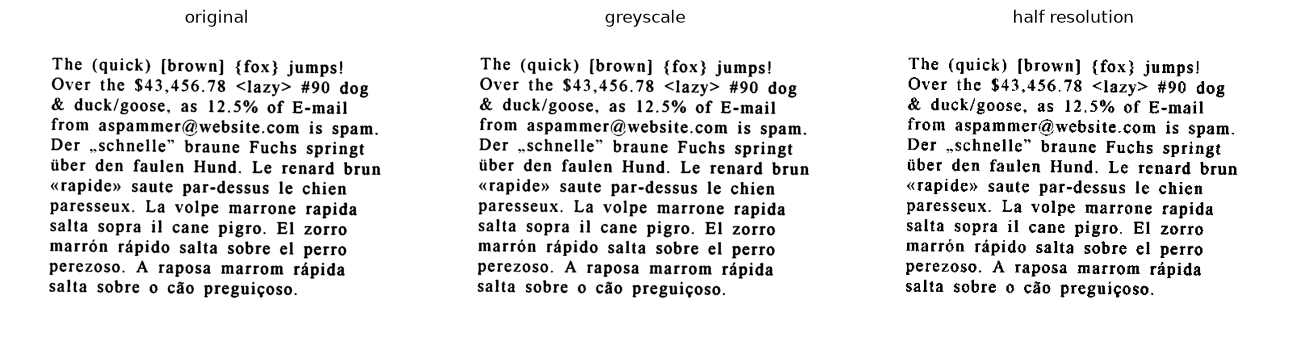

  original            66 words, C_page=0.914


  greyscale           66 words, C_page=0.914


  half resolution     66 words, C_page=0.897


In [16]:
# Only run if the toolchain is available.
if TESSERACT_OK and PIL is not None:

    # Import image handling.
    from PIL import Image

    # Load the multilingual scan - the harder of our two images.
    original = Image.open(eurotext_path)

    # Variant A: the image exactly as-is.
    # Variant B: converted to greyscale, which often helps Tesseract.
    # Variant C: downscaled by half, simulating a low-resolution capture.
    variants = {
        "original": original,
        "greyscale": original.convert("L"),
        "half resolution": original.resize(
            (original.width // 2, original.height // 2)
        ),
    }

    # Show every variant so the preprocessing is visible, not just its score.
    figure, axes = plt.subplots(1, len(variants), figsize=(13, 4))
    for axis, (name, image) in zip(axes, variants.items()):
        axis.imshow(image, cmap="gray" if image.mode == "L" else None)
        axis.axis("off")
        axis.set_title(name)
    plt.tight_layout()
    plt.show()

    # OCR each variant and compare confidence.
    for name, image in variants.items():

        # Get word-level data for this variant.
        data = pytesseract.image_to_data(image, output_type=pytesseract.Output.DICT)

        # Keep real words with valid confidence.
        confidences = [int(c) for t, c in zip(data["text"], data["conf"])
                       if t.strip() and int(c) >= 0]

        # Average them into a page score.
        score = sum(confidences) / len(confidences) / 100 if confidences else 0.0

        # Report words found and confidence.
        print(f"  {name:18s} {len(confidences):3d} words, C_page={score:.3f}")

### Reading that result honestly

**Greyscale changed nothing here** — the Tesseract test images are already 1-bit bitonal, so
there was no colour information to discard, and the image above looks identical. That is worth
knowing: preprocessing steps are not universally beneficial, and blindly applying a pipeline of
them wastes compute.

**Half resolution did cost confidence.** The image above visibly softens; if your ingestion
renders pages at 72 dpi to save memory, that is the quality you are silently accepting. DPI is
not a performance knob — it is an accuracy knob that happens to have a performance cost.

> **The general rule:** measure each preprocessing step on *your* documents. A step that
> transforms a colour phone photo dramatically may be a no-op on a clean bitonal fax.

# 6. Module summary

## Key points

1. **A scanned PDF fails silently** — extraction returns `""`, not an error. Always validate.
2. **DPI is an accuracy setting.** 300 dpi is the usual OCR sweet spot; 72 dpi loses words.
3. **Use the confidence score.** Three tiers (accept / flag / reject) beats binary.
4. **Store per-word confidence**, so you can flag passages rather than whole documents.
5. **OCR confusions are near-misses**, which is what makes them dangerous.
6. **Route, don't blanket-OCR.** The difference is tens of thousands of dollars at scale.
7. **Flag, don't auto-correct.** `modern` → `modem` is worse than leaving it alone.

## Key formulas

| Formula | Meaning |
|---|---|
| $C_{\text{page}} = \frac{1}{N}\sum c_i$ | Page-level OCR confidence |
| $N_{\text{docs}} \times f_{\text{scanned}} \times P \times \text{cost}$ | Routed OCR cost |

## Interview answer: "How do you ingest a scanned PDF?"

> 1. Detect insufficient embedded text
> 2. Render the page to an image at ~300 dpi
> 3. Preprocess if necessary (deskew, denoise, contrast, orientation)
> 4. Run OCR
> 5. Capture words **plus bounding boxes plus confidence**
> 6. Perform layout analysis
> 7. Reconstruct reading order
> 8. Extract headings / tables / paragraphs
> 9. Validate OCR quality against a threshold and route low-confidence pages
> 10. Preserve page-level provenance
>
> I route rather than OCR everything — at a million documents, blanket OCR costs roughly
> \$50K against \$4K for routing, and it adds latency for no benefit on born-digital files.

## Exercises

1. **Find the DPI floor.** OCR the W-4 at 72, 100, 150, 200, 300 dpi. Plot confidence against
   DPI. Where does quality collapse?
2. **Build a confusion corrector.** Given a known vocabulary of regulation numbers, write a
   corrector that fixes `184I` → `1847` *only* when the corrected form is in the vocabulary.
3. **Measure preprocessing.** Add deskew (rotate the image 2°, then correct it) and measure
   the confidence recovery.
4. **Cost-model your own corpus.** What scanned fraction makes a commercial OCR API cheaper
   than self-hosting Tesseract, assuming your engineering time is worth \$X/hour?

## Next: [Module 2d — DOCX, HTML & Markdown](../2d.%20DOCX%20HTML%20and%20markdown/)

After the difficulty of PDF and OCR, these formats are a relief: they **carry their own
structure**. We extract real heading hierarchies and see what that buys us at chunking time.